# Project for Neuroinformatics WiSe 2024/2025

**By Sören Dänekas*
1009226
----


This jupyter notebook expects all packages from the ``requirements.txt`` installed in an activated environment and the data directory adjancend to this notebook.

All cells may be run from the top to the bottom, each at a time.

Assignment formulations and project specification was taken from the NI_project.pdf provided by the lecturee.

Used naming schema: [German Naming Convention](https://chrisdone.com/posts/german-naming-convention/)

----

# Data

X: spike trains from multiple neurons. Shape: (samples, neurons, timesteps)

y: input familiarity.

# Task


You have recorded firing activity from multiple neurons in response to various stimuli. Some stimuli are familiar to the neurons, while others are new / surprising. Your goal is to develop a binary classifier that determines, based on the neural activity, whether a given stimulus was familiar or unfamiliar.

You conducted 800 experiments in total, so you have 800 data samples, each containing information about firing of all neurons in response to a single stimulus.

# Requirements

1. A github repository with the coding solution implemented in Python3 with the use of scikit-learn package. It should contain one Jupyter Notebook file which includes all the steps + the requirements.txt file + slides in a PDF format (see Requirement 4).

2. The code in your Jupyter Notebook file should be clearly commented, with the explanation of all steps and interpretation of all outputs and results. 
For steps which ask to justify your choice - write the justification, using any statistical or visualization methods if necessary.

3. A requirements file in the repository should mention any additional packages necessary
to run your code (the fewer - the better. Ideally, try to only use any combination of the
following packages: 
- numpy, 
- scipy, 
- pandas, 
- scikit-learn 
- and matplotlib). 

We should be able to run your code without errors.

4. Prepare several slides which include: 
- a) a brief explanation of methods and metrics used; 
- b) the results; 
- c) your interpretation of the results. 

We might ask you to present your solution for the project using these slides. 

Upload these slides in a PDF format to the repository.

5. Don’t forget to include your first and last name + your matriculation number in both
Jupyter Notebook and a PDF file


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, classification_report
from scipy.signal import convolve

# an array of 800 samples, where each consists of:
#     1000 neurons, where each neuron consists of:
#          501 timesteps, where each timestep is represented as a boolean value, which signals whether that neuron fires at that timestep  
spike_trains = np.load('./data/x.npy')

sample_count, neuron_count, timestep_count = spike_trains.shape

# 1D boolean array of 800 samples, whether the sample at array position is familiar or unfamiliar
input_familiarity = np.load('./data/y.npy') == 1

## 1. Visualization of the data

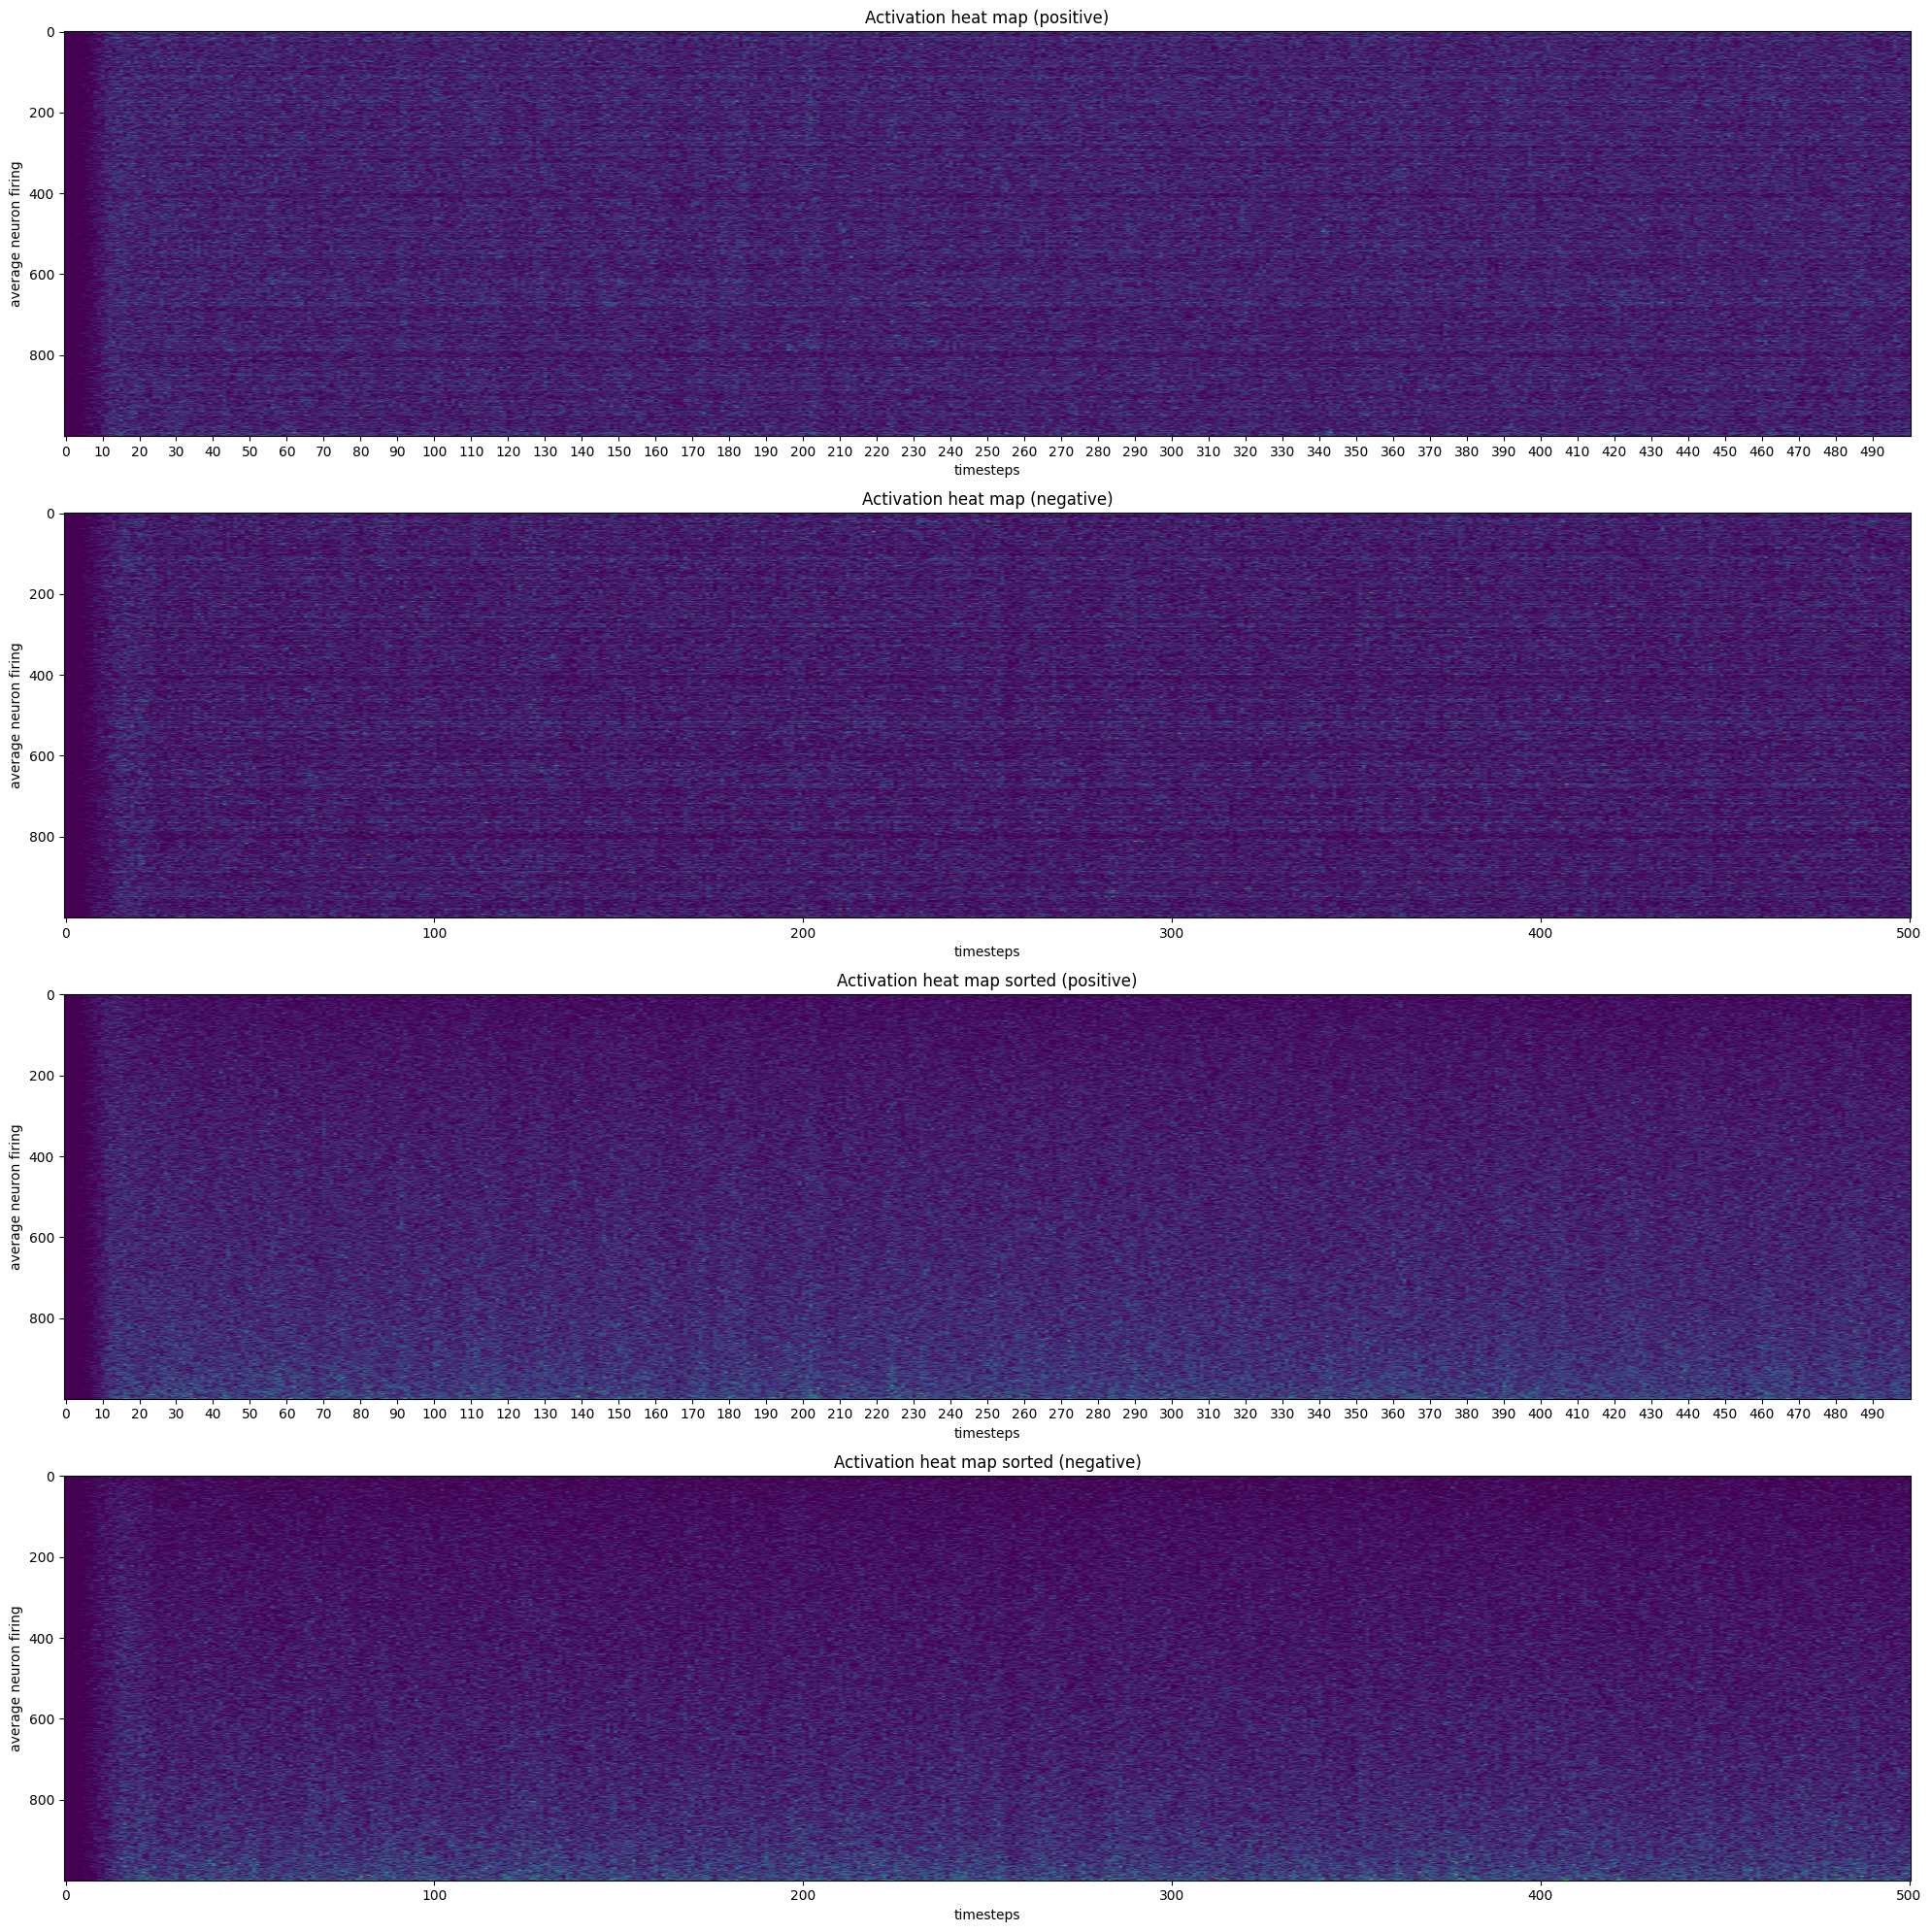

In [8]:
## Goal: 
# Show a 2D grafic (timestep / neuron) as a heatmap separated by negative and positive input familiarity.
## Intention:
# Make patterns visible over the average of the neuron activation patterns visible. 

# split the samples by input_familiarity
positive = spike_trains[input_familiarity]
negative = spike_trains[input_familiarity == False]

# average over all samples the neuron activation per timestep
mean_positive = positive.mean(axis=0)
mean_negative = negative.mean(axis=0)

# Presenting negative and positive smaples
fig, (axp, axn,axps, axns) = plt.subplots(4)
fig.set_size_inches(20, 20)

axp.set_title("Activation heat map (positive)")
axp.set_xlabel("timesteps")
axp.set_ylabel("average neuron firing")
axp.set_xticks(range(0, 500, 10))
axp.imshow(mean_positive, aspect='auto')

axps.set_title("Activation heat map sorted (positive)")
axps.set_xlabel("timesteps")
axps.set_ylabel("average neuron firing")
axps.set_xticks(range(0, 500, 10))
axps.imshow(mean_positive[np.argsort(mean_positive.sum(1))], aspect='auto')

axn.set_title("Activation heat map (negative)")
axn.set_xlabel("timesteps")
axn.set_ylabel("average neuron firing")
axn.imshow(mean_negative, aspect='auto')

axns.set_title("Activation heat map sorted (negative)")
axns.set_xlabel("timesteps")
axns.set_ylabel("average neuron firing")
axns.imshow(mean_negative[np.argsort(mean_negative.sum(1))], aspect='auto')

fig.tight_layout(h_pad=1)

Observations:

- We have a quite noisy recording.
- From timestep 1 to about 8 or 9 most neurons are not firing.
- Some neurons are more active over the timesteps than others (horizontal dark or bright lines are visible)
- Some neurons seem to correlate in activation (Vertical columns a slightly visible)

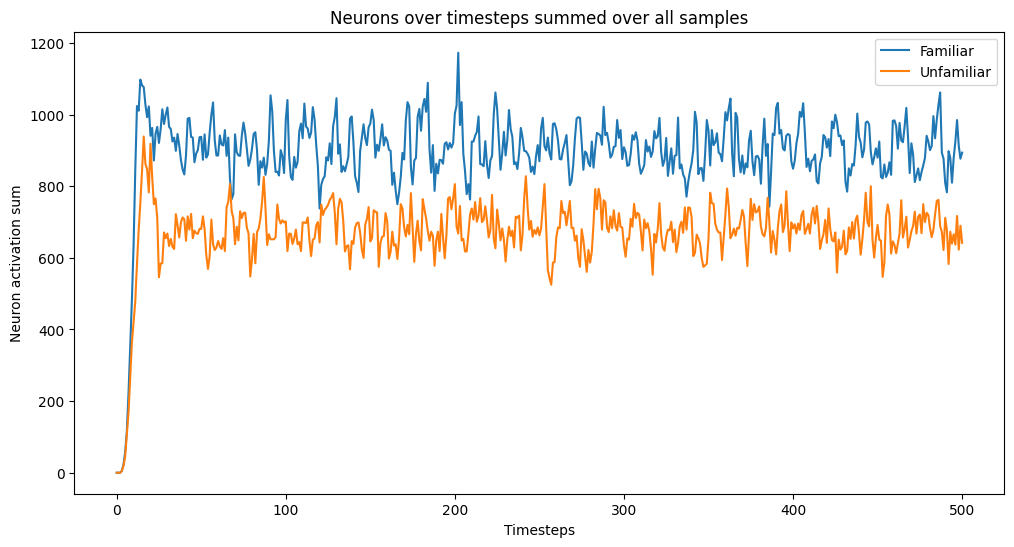

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(positive.sum(axis=(0,1)), label='Familiar')
plt.plot(negative.sum(axis=(0,1)), label='Unfamiliar')
plt.xlabel('Timesteps')
plt.ylabel('Neuron activation sum')
plt.title('Neurons over timesteps summed over all samples')
plt.legend()
plt.show()

Observations:
- There is an initial spike between about 5 and 20 in both positive and negative.
- The positive initial spike is longer and taller than the negative condition.

# 2. Prepare data for classification


Decide how to transform raw spikes into data suitable for classification, 

e.g. 
measure the
- average firing rate of all neurons or some group of neurons, 
- their firing synchrony, 
- make a Fourier transformation, 
- etc. 

Hint: search for various neural coding methods.

### Rate coding: Spike-count rate

The average firing rate of all neurons for each sample.

In [10]:
coded_spike_count_rate = spike_trains.sum(axis=2)

print(coded_spike_count_rate.shape)

(800, 1000)


### Temporal coding: Time to first spike

In [11]:
# Replace (neuron, timesteps[bool]) with (neuron_time_to_first_spike[int])
coded_time_to_first_spike = np.argmax(spike_trains, axis=2)

# Set no-spike to 501
coded_time_to_first_spike[~spike_trains.any(axis=2)] = timestep_count

# outputshape: (sample, neuron_time_to_first_spike)
# neurons, that do not spike have index 501.

print(coded_time_to_first_spike.shape)

(800, 1000)


### Temporal coding: Phase of firing / Frequency of highest Amplitude / Variation of frequencies

Use a fourier transform over each neuron, to find out which phases or amplitudes of frequencies are contained in the firing pattern.

In [12]:
# Requires around 16 gigs of ram!

# use rfft, to spare memory
fft_result = np.fft.rfft(spike_trains, axis=-1)
frequencies = np.fft.rfftfreq(timestep_count)

# Only take frequencies > 0, preventing polluting the regression
valid_frequencys = frequencies > 0  # Mask to exclude 0
frequencies_over_zero = frequencies[valid_frequencys]
fft_result_over_zero = fft_result[..., valid_frequencys]

# Extract highest frequency amplitude
coded_highest_amplitude = frequencies_over_zero[np.argmax(np.abs(fft_result_over_zero), axis=-1)]

phases = np.angle(fft_result)

# Extract phase information
coded_phase_of_firing = phases.reshape(sample_count, -1)

del fft_result # free memory, since this variable is not needed anymore
del fft_result_over_zero # free memory, since this variable is not needed anymore


print(coded_phase_of_firing.shape)
print(coded_highest_amplitude.shape)

(800, 251000)
(800, 1000)


### Population coding: Population Variance

In [13]:
coded_population_variance = np.var(np.mean(spike_trains, axis=1), axis=1).reshape(-1, 1)

print(coded_population_variance.shape)

(800, 1)


### Population coding: Average Population activity

In [14]:
coded_population_average = np.mean(spike_trains, axis=1)

print(coded_population_average.shape)

(800, 501)


# 3. Exploratory analysis


When you have data ready for classification, first do the exploratory analysis: 
- plot the distributions of your data for familiar and new classes, and 
- measure the difference between these distributions, using one or more metrics learned in the course. 

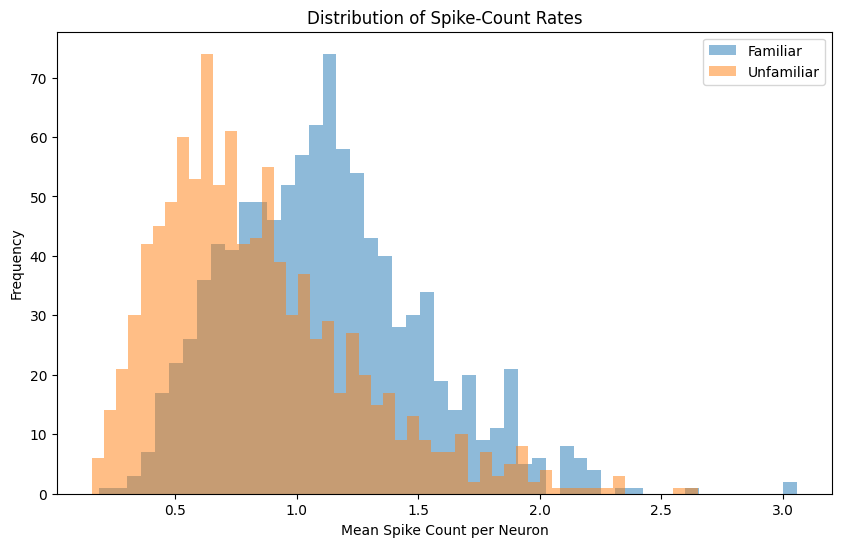

In [15]:
mean_spike_positive = coded_spike_count_rate[input_familiarity].mean(axis=0)
mean_spike_negative = coded_spike_count_rate[~input_familiarity].mean(axis=0)

# Plot distributions
plt.figure(figsize=(10, 6))
plt.hist(mean_spike_positive, bins=50, alpha=0.5, label='Familiar')
plt.hist(mean_spike_negative, bins=50, alpha=0.5, label='Unfamiliar')
plt.xlabel('Mean Spike Count per Neuron')
plt.ylabel('Frequency')
plt.title('Distribution of Spike-Count Rates')
plt.legend()
plt.show()

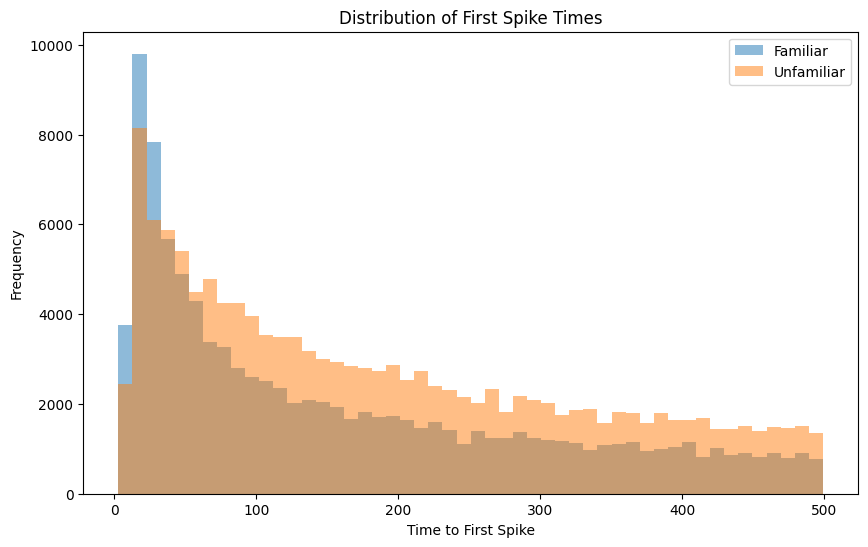

In [16]:
# Flatten data across samples and neurons
first_spike_positive = coded_time_to_first_spike[input_familiarity].flatten()
first_spike_negative = coded_time_to_first_spike[~input_familiarity].flatten()

# Plot distributions (truncate at 500 timesteps)
plt.figure(figsize=(10, 6))
plt.hist(first_spike_positive[first_spike_positive < 500], bins=50, alpha=0.5, label='Familiar')
plt.hist(first_spike_negative[first_spike_negative < 500], bins=50, alpha=0.5, label='Unfamiliar')
plt.xlabel('Time to First Spike')
plt.ylabel('Frequency')
plt.title('Distribution of First Spike Times')
plt.legend()
plt.show()

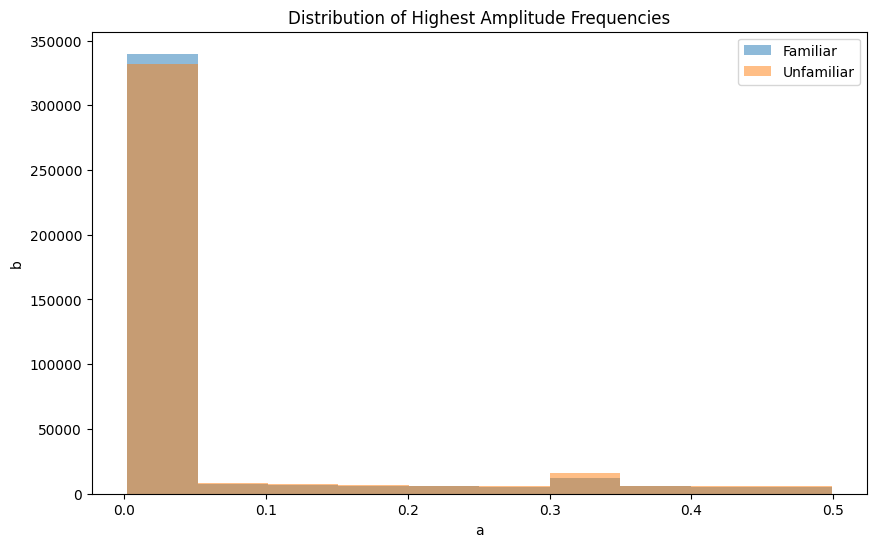

In [17]:
# Flatten data across samples and neurons
freq_positive = coded_highest_amplitude[input_familiarity].flatten()
freq_negative = coded_highest_amplitude[~input_familiarity].flatten()

# Plot distributions
plt.figure(figsize=(10, 6))
plt.hist(freq_positive, alpha=0.5, label='Familiar')
plt.hist(freq_negative, alpha=0.5, label='Unfamiliar')
plt.xlabel('a')
plt.ylabel('b')
plt.title('Distribution of Highest Amplitude Frequencies')
plt.legend()
plt.show()

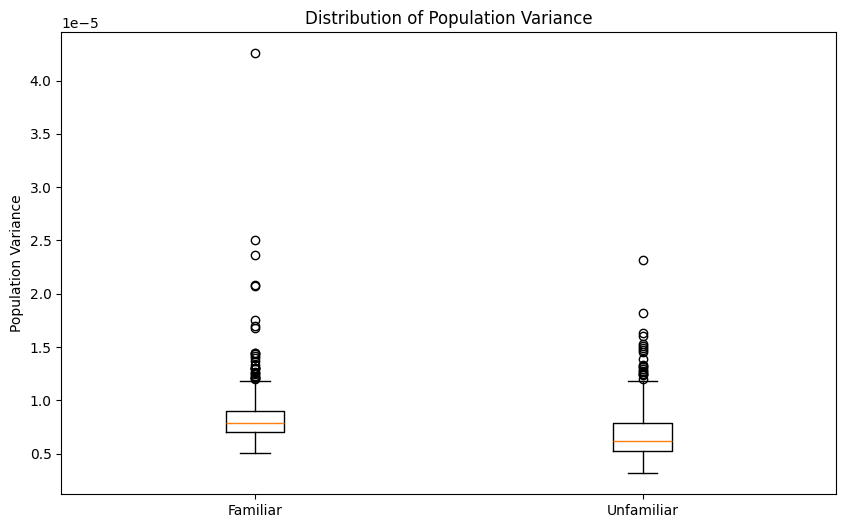

In [18]:
plt.figure(figsize=(10, 6))
plt.boxplot([coded_population_variance[input_familiarity].flatten(),
             coded_population_variance[~input_familiarity].flatten()],
            tick_labels=['Familiar', 'Unfamiliar'])
plt.ylabel('Population Variance')
plt.title('Distribution of Population Variance')
plt.show()

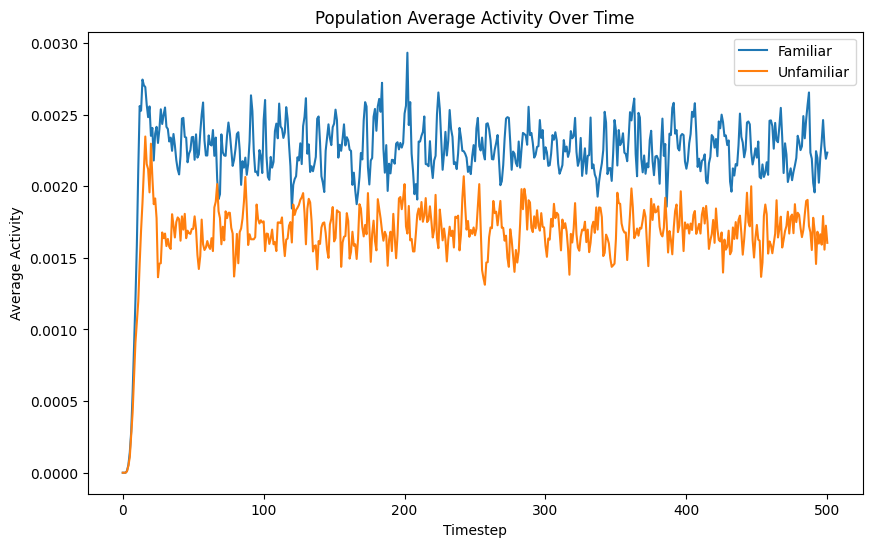

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(coded_population_average[input_familiarity].mean(axis=0), label='Familiar')
plt.plot(coded_population_average[~input_familiarity].mean(axis=0), label='Unfamiliar')
plt.xlabel('Timestep')
plt.ylabel('Average Activity')
plt.title('Population Average Activity Over Time')
plt.legend()
plt.show()

# 4. Create and train a model

Finally, create and train a model for predicting the class of your data: familiar or new.


Hint: you can either use Logistic regression or find some other classification method
that we did not study in the course. 

Justify your choice of the method.

In [20]:
# Since the input has a high size, a higher than default max_iter is needed.

scaler = StandardScaler()

def createLogistic():
    return LogisticRegression(max_iter=3000)

# Next every coded dataset gets split into test and train.

In [21]:
coded_spike_count_rate_split = train_test_split(scaler.fit_transform(coded_spike_count_rate), input_familiarity)
coded_spike_count_rate_x_train = coded_spike_count_rate_split[0]
coded_spike_count_rate_x_test = coded_spike_count_rate_split[1]
coded_spike_count_rate_y_train = coded_spike_count_rate_split[2]
coded_spike_count_rate_y_test = coded_spike_count_rate_split[3]

coded_spike_count_rate_model = createLogistic().fit(coded_spike_count_rate_x_train, coded_spike_count_rate_y_train)

In [22]:
coded_time_to_first_spike_split = train_test_split(scaler.fit_transform(coded_time_to_first_spike), input_familiarity)
coded_time_to_first_spike_x_train = coded_time_to_first_spike_split[0]
coded_time_to_first_spike_x_test = coded_time_to_first_spike_split[1]
coded_time_to_first_spike_y_train = coded_time_to_first_spike_split[2]
coded_time_to_first_spike_y_test = coded_time_to_first_spike_split[3]

coded_time_to_first_spike_model = createLogistic().fit(coded_time_to_first_spike_x_train, coded_time_to_first_spike_y_train)


In [23]:
coded_phase_of_firing_split = train_test_split(scaler.fit_transform(coded_phase_of_firing), input_familiarity)
coded_phase_of_firing_x_train = coded_phase_of_firing_split[0]
coded_phase_of_firing_x_test = coded_phase_of_firing_split[1]
coded_phase_of_firing_y_train = coded_phase_of_firing_split[2]
coded_phase_of_firing_y_test = coded_phase_of_firing_split[3]

coded_phase_of_firing_model = createLogistic().fit(coded_phase_of_firing_x_train, coded_phase_of_firing_y_train)

In [24]:
coded_highest_amplitude_split = train_test_split(scaler.fit_transform(coded_highest_amplitude), input_familiarity)
coded_highest_amplitude_x_train = coded_highest_amplitude_split[0]
coded_highest_amplitude_x_test = coded_highest_amplitude_split[1]
coded_highest_amplitude_y_train = coded_highest_amplitude_split[2]
coded_highest_amplitude_y_test = coded_highest_amplitude_split[3]

coded_highest_amplitude_model = createLogistic().fit(coded_highest_amplitude_x_train, coded_highest_amplitude_y_train)

In [25]:
coded_average_amplitude

coded_average_amplitude_split = train_test_split(scaler.fit_transform(coded_average_amplitude), input_familiarity)
coded_average_amplitude_x_train = coded_average_amplitude_split[0]
coded_average_amplitude_x_test = coded_average_amplitude_split[1]
coded_average_amplitude_y_train = coded_average_amplitude_split[2]
coded_average_amplitude_y_test = coded_average_amplitude_split[3]

coded_average_amplitude_model = createLogistic().fit(coded_average_amplitude_x_train, coded_average_amplitude_y_train)

NameError: name 'coded_average_amplitude' is not defined

In [ ]:
coded_population_variance_split = train_test_split(scaler.fit_transform(coded_population_variance), input_familiarity)

coded_population_variance_x_train = coded_population_variance_split[0]
coded_population_variance_x_test = coded_population_variance_split[1]
coded_population_variance_y_train = coded_population_variance_split[2]
coded_population_variance_y_test = coded_population_variance_split[3]

coded_population_variance_model = createLogistic().fit(coded_population_variance_x_train, coded_population_variance_y_train)

In [ ]:
coded_population_average_split = train_test_split(scaler.fit_transform(coded_population_average), input_familiarity)

coded_population_average_x_train = coded_population_average_split[0]
coded_population_average_x_test = coded_population_average_split[1]
coded_population_average_y_train = coded_population_average_split[2]
coded_population_average_y_test = coded_population_average_split[3]

coded_population_average_model = createLogistic().fit(coded_population_average_x_train, coded_population_average_y_train)

# 5. Evaluate model performance

Evaluate the model performance. 

Use a specialized metric for classification
performance, such as 
- Accuracy, 
- F1-score 
- or similar. 

Justify the choice of a metric

In [ ]:
coded_spike_count_rate_y_predicted = coded_spike_count_rate_model.predict(coded_spike_count_rate_x_test)

print(classification_report(coded_spike_count_rate_y_test, coded_spike_count_rate_y_predicted))

In [ ]:
coded_time_to_first_spike_y_predicted = coded_time_to_first_spike_model.predict(coded_time_to_first_spike_x_test)

print(classification_report(coded_time_to_first_spike_y_test, coded_time_to_first_spike_y_predicted))

In [ ]:
coded_phase_of_firing_y_predicted = coded_phase_of_firing_model.predict(coded_phase_of_firing_x_test)

print(classification_report(coded_phase_of_firing_y_test, coded_phase_of_firing_y_predicted))

In [ ]:
coded_highest_amplitude_y_predicted = coded_highest_amplitude_model.predict(coded_highest_amplitude_x_test)

print(classification_report(coded_highest_amplitude_y_test, coded_highest_amplitude_y_predicted))

In [ ]:
coded_population_variance_y_predicted = coded_population_variance_model.predict(coded_population_variance_x_test)

print(classification_report(coded_population_variance_y_test, coded_population_variance_y_predicted))

In [ ]:
coded_average_amplitude_y_predicted = coded_average_amplitude_model.predict(coded_average_amplitude_x_test)

print(classification_report(coded_average_amplitude_y_test, coded_average_amplitude_y_predicted))

In [ ]:
coded_population_average_y_predicted = coded_population_average_model.predict(coded_population_average_x_test)

print(classification_report(coded_population_average_y_test, coded_population_average_y_predicted))

# 6. Comparing multiple models



Compare multiple models, performing steps 1-4 for at least one of the following cases:
- a) different amount of X features used for classification
- b) different neural coding methods for spiking data transformation
- c) different classification methods
- d) different basis functions